# Test Graph 3 Plot

Plot corrected fidelity and latency for the `test_graph3` two-qubit-gate sweep.


In [21]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


In [22]:
line_re = re.compile(
    r"run_id=(?P<run_id>\d+), time to serve=(?P<latency>[-+0-9.eE]+), "
    r"(?:fidelity_raw=(?P<fidelity_raw>[-+0-9.eE]+), fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+), )?"
    r"fidelity=(?P<fidelity>[-+0-9.eE]+)"
)

filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"(?:physbell=(?P<physbell>[0-9.]+|cfg),)?"
    r"ts=(?P<ts>\d{8}_\d{4})"
)


In [23]:
def load_runner_logs(log_dir: Path) -> pd.DataFrame:
    """Load one runner log directory into a flat dataframe.

    Args:
        log_dir: Directory containing runner log files.

    Returns:
        pd.DataFrame: One row per completed run.
    """
    rows = []
    for path in sorted(log_dir.iterdir()):
        if not path.is_file() or path.stat().st_size == 0:
            continue
        filename_match = filename_re.search(path.name)
        if filename_match is None:
            continue

        meta = filename_match.groupdict()
        log_mtime = path.stat().st_mtime
        nodes = int(meta["nodes"])
        num_links = nodes - 1
        elementary_link_km = float(meta["dist"])
        total_distance_km = num_links * elementary_link_km
        t2_value = float(meta["t2"])

        with path.open("r", encoding="utf-8") as file:
            for line in file:
                line_match = line_re.search(line)
                if line_match is None:
                    continue
                rows.append({
                    "log_name": path.name,
                    "log_mtime": log_mtime,
                    "nodes": nodes,
                    "num_links": num_links,
                    "elementary_link_km": elementary_link_km,
                    "total_distance_km": total_distance_km,
                    "css_code": meta["code"],
                    "two_qubit_gate_fidelity": float(meta["twoq"]),
                    "gate_fidelity": float(meta["gate"]),
                    "state_preparation_fidelity": float(meta["prep"]),
                    "physical_bell_pair_fidelity": None if meta.get("physbell") in (None, "cfg") else float(meta["physbell"]),
                    "data_t2": t2_value,
                    "comm_t2": t2_value,
                    "t1": float(meta["t1"]),
                    "correction_mode": meta["ccorr"],
                    "ft_prep_mode": meta["ft"],
                    "run_id": int(line_match["run_id"]),
                    "latency_ms": float(line_match["latency"]),
                    "fidelity": float(line_match["fidelity"]),
                    "fidelity_raw": float(line_match["fidelity_raw"]) if line_match["fidelity_raw"] is not None else float(line_match["fidelity"]),
                    "fidelity_corrected": float(line_match["fidelity_corrected"]) if line_match["fidelity_corrected"] is not None else float(line_match["fidelity"]),
                })
    return pd.DataFrame(rows)


Using log_dir: /Users/patange/Documents/Argonne/QEC/log/runner-ideal/test_graph3
Exists: True
row_count: 7350
   two_qubit_gate_fidelity correction_mode  fidelity_corrected  latency_ms
0                    0.995             cec                 1.0    3.545314
1                    0.995             cec                 1.0    2.445266
2                    0.995             cec                 1.0    2.005154
3                    0.995             cec                 1.0    2.940254
4                    0.995             cec                 1.0    2.995219
modes: ['cec']
twoq: [np.float64(0.995), np.float64(0.996), np.float64(0.997), np.float64(0.998), np.float64(0.999), np.float64(0.9995), np.float64(1.0)]


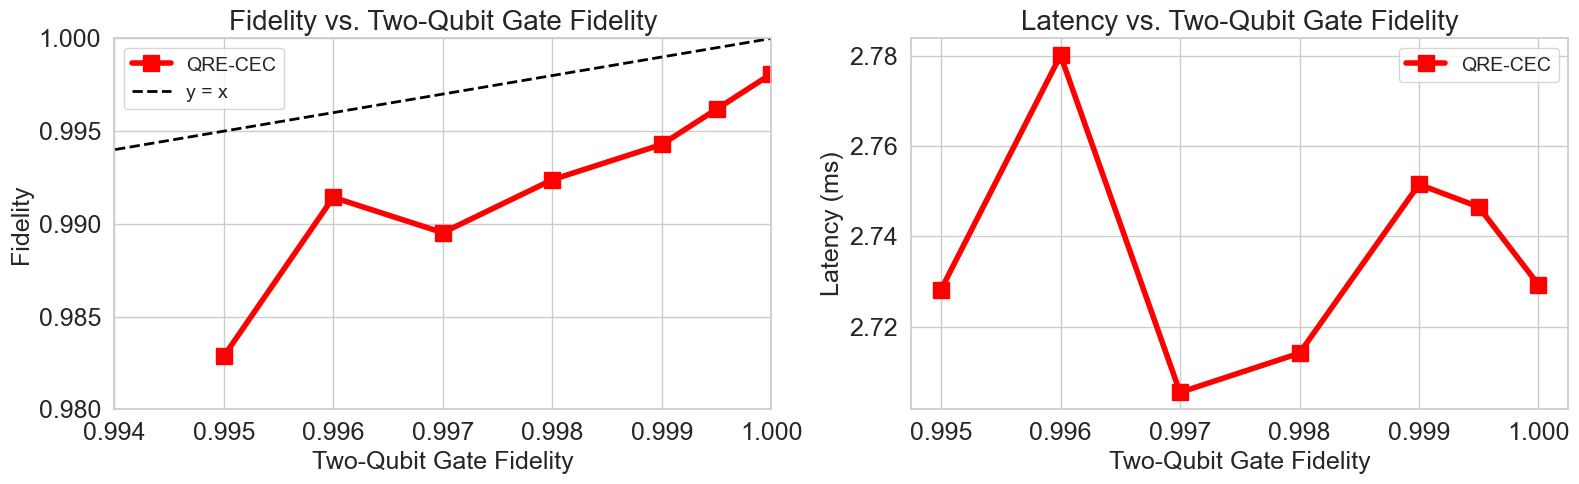

In [27]:
project_dir = Path.cwd()
if not (project_dir / "log").exists() and (project_dir / "QEC" / "log").exists():
    project_dir = project_dir / "QEC"

log_dir = project_dir / "log" / "runner-ideal" / "test_graph3"
output_dir = project_dir / "plot_pngs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Using log_dir:", log_dir)
print("Exists:", log_dir.exists())

test_graph3_df = load_runner_logs(log_dir)

print("row_count:", len(test_graph3_df))
if not test_graph3_df.empty:
    print(test_graph3_df[["two_qubit_gate_fidelity", "correction_mode", "fidelity_corrected", "latency_ms"]].head())
    print("modes:", sorted(test_graph3_df["correction_mode"].unique()))
    print("twoq:", sorted(test_graph3_df["two_qubit_gate_fidelity"].unique()))

if test_graph3_df.empty:
    print("No test_graph3 data found.")
else:
    test_graph3_summary = (
        test_graph3_df.groupby(["two_qubit_gate_fidelity", "correction_mode"], as_index=False)
        .agg(
            mean_fidelity_corrected=("fidelity_corrected", "mean"),
            mean_latency_ms=("latency_ms", "mean"),
        )
        .sort_values(["two_qubit_gate_fidelity", "correction_mode"])
        .reset_index(drop=True)
    )

    colors = {"cec": "red", "none": "blue", "qec": "green"}
    names = {"cec": "QRE-CEC", "none": "QRE-None", "qec": "QRE-QEC"}
    markers = {"cec": "s", "none": "^", "qec": "o"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax0 = axes[0]
    ax1 = axes[1]

    for protocol in sorted(test_graph3_summary["correction_mode"].unique()):
        data = test_graph3_summary[test_graph3_summary["correction_mode"] == protocol]
        ax0.plot(
            data["two_qubit_gate_fidelity"],
            data["mean_fidelity_corrected"],
            color=colors.get(protocol, "black"),
            marker=markers.get(protocol, "o"),
            linewidth=4,
            markersize=12,
            linestyle="-",
            label=names.get(protocol, protocol),
        )
        ax1.plot(
            data["two_qubit_gate_fidelity"],
            data["mean_latency_ms"],
            color=colors.get(protocol, "black"),
            marker=markers.get(protocol, "o"),
            linewidth=4,
            markersize=12,
            label=names.get(protocol, protocol),
        )

    lower = min(test_graph3_summary["two_qubit_gate_fidelity"].min(), test_graph3_summary["mean_fidelity_corrected"].min())
    upper = max(test_graph3_summary["two_qubit_gate_fidelity"].max(), test_graph3_summary["mean_fidelity_corrected"].max())
    ax0.plot([lower, upper], [lower, upper], color="black", linestyle="--", linewidth=2, label="y = x")

    ax0.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
    ax0.set_ylabel("Fidelity", fontsize=18)
    ax0.set_title("Fidelity vs. Two-Qubit Gate Fidelity", fontsize=20)
    ax0.axhline(0.25, color="black", linestyle="--", linewidth=2, label="_nolegend_")
    ax0.set_ylim(0.98, 1)
    ax0.set_xlim(0.994, 1)

    ax0.tick_params(axis="both", labelsize=18)
    ax0.legend(fontsize=14)

    ax1.set_xlabel("Two-Qubit Gate Fidelity", fontsize=18)
    ax1.set_ylabel("Latency (ms)", fontsize=18)
    ax1.set_title("Latency vs. Two-Qubit Gate Fidelity", fontsize=20)
    ax1.tick_params(axis="both", labelsize=18)
    ax1.legend(fontsize=14)

    plt.tight_layout()
    plt.savefig(output_dir / "test_graph3_two_qubit_gate_sweep.png", dpi=300, bbox_inches="tight")
    plt.show()

    test_graph3_summary
